# ANÁLISIS DE DESBALANCE Y OVERSAMPLING

## Objetivo
Analizar el desbalance de clases y aplicar **Random OverSampler (ROS)** para las clases
con léxico explícito (`hemorragia`, `acv`).

## Decisión metodológica
El análisis de desbalance reveló cuatro clases con perfiles muy distintos:

| Clase | Positivos | Ratio | Estrategia |
|-------|-----------|-------|------------|
| `hemorragia` | 3319 | 1:0.2 | **Sin augmentation** — clase dominante |
| `acv` | 1751 | 1:1.3 | **ROS** — léxico explícito y bien representado |
| `desviacion_linea_media` | 52 | 1:75 | **LLM augmentation** (notebook 1b) |
| `fractura_compleja_craneo` | 60 | 1:65 | **LLM augmentation** (notebook 1b) |

SMOTE se descarta por operar sobre vectores TF-IDF: la interpolación entre puntos
en el espacio de frecuencias de términos produce vectores sin correspondencia con
ningún texto médico plausible, introduciendo ruido semántico en las clases más escasas.
Para esas clases se utiliza generación LLM con imitación de estilo (notebook 1b).

**Referencia:** Veselovsky et al. (2023). *Artificial Intelligence with Purpose.* Stanford HAI.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler

plt.style.use('default')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')
print('Dependencias cargadas.')

Dependencias cargadas.


## 1. Carga de datos y análisis de desbalance

In [3]:
# Cargar dataset procesado
df = pd.read_excel('../data/rad_criticos.xlsx')

print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)
print(f"\nTotal de registros: {len(df)}")
print(f"Columnas: {df.shape[1]}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

# Variables de entrada y etiquetas
patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
print(f"\n{'='*60}")
print(f"PATOLOGÍAS A CLASIFICAR: {patologias}")
print(f"{'='*60}")

INFORMACIÓN DEL DATASET

Total de registros: 952
Columnas: 15

Columnas disponibles:
['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal', 'texto_informe', 'texto_normalizado', 'rad_prediccion', 'rad_score']

PATOLOGÍAS A CLASIFICAR: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


In [4]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Distribución de etiquetas generadas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [5]:
# ANÁLISIS DE DESBALANCE POR CLASE
print("\n" + "="*60)
print("DISTRIBUCIÓN DE CLASES (ANÁLISIS DE DESBALANCE)")
print("="*60)

# Contar casos positivos por clase
class_counts = {}
for patologia in patologias:
    positivos = df[patologia].sum()
    negativos = len(df) - positivos
    ratio = positivos / len(df) * 100
    
    class_counts[patologia] = {
        'positivos': positivos,
        'negativos': negativos,
        'total': len(df),
        'ratio_positivos': ratio
    }
    
    print(f"\n{patologia.upper()}")
    print(f"  Positivos (1): {positivos:4d} ({ratio:5.2f}%)")
    print(f"  Negativos (0): {negativos:4d} ({100-ratio:5.2f}%)")
    print(f"  Ratio 1:0 = 1:{negativos/positivos:.2f}")

# Calcular imbalance ratio promedio
ratios = [v['negativos']/v['positivos'] for v in class_counts.values()]
avg_imbalance = np.mean(ratios)

print(f"\n{'='*60}")
print(f"RESUMEN DE DESBALANCE")
print(f"{'='*60}")
print(f"Ratio de desbalance promedio: 1:{avg_imbalance:.2f}")

if avg_imbalance > 3:
    print("  DESBALANCE MODERADO-ALTO detectado")
    print("   Recomendación: Aplicar técnicas de balanceo")
elif avg_imbalance > 1.5:
    print("  DESBALANCE LEVE detectado")
    print("   Recomendación: Considerar class_weight o oversampling")
else:
    print("  Clases relativamente balanceadas")


DISTRIBUCIÓN DE CLASES (ANÁLISIS DE DESBALANCE)

ACV
  Positivos (1):  323 (33.93%)
  Negativos (0):  629 (66.07%)
  Ratio 1:0 = 1:1.95

HEMORRAGIA
  Positivos (1):  813 (85.40%)
  Negativos (0):  139 (14.60%)
  Ratio 1:0 = 1:0.17

DESVIACION_LINEA_MEDIA
  Positivos (1):  129 (13.55%)
  Negativos (0):  823 (86.45%)
  Ratio 1:0 = 1:6.38

FRACTURA_COMPLEJA_CRANEO
  Positivos (1):   30 ( 3.15%)
  Negativos (0):  922 (96.85%)
  Ratio 1:0 = 1:30.73

RESUMEN DE DESBALANCE
Ratio de desbalance promedio: 1:9.81
  DESBALANCE MODERADO-ALTO detectado
   Recomendación: Aplicar técnicas de balanceo


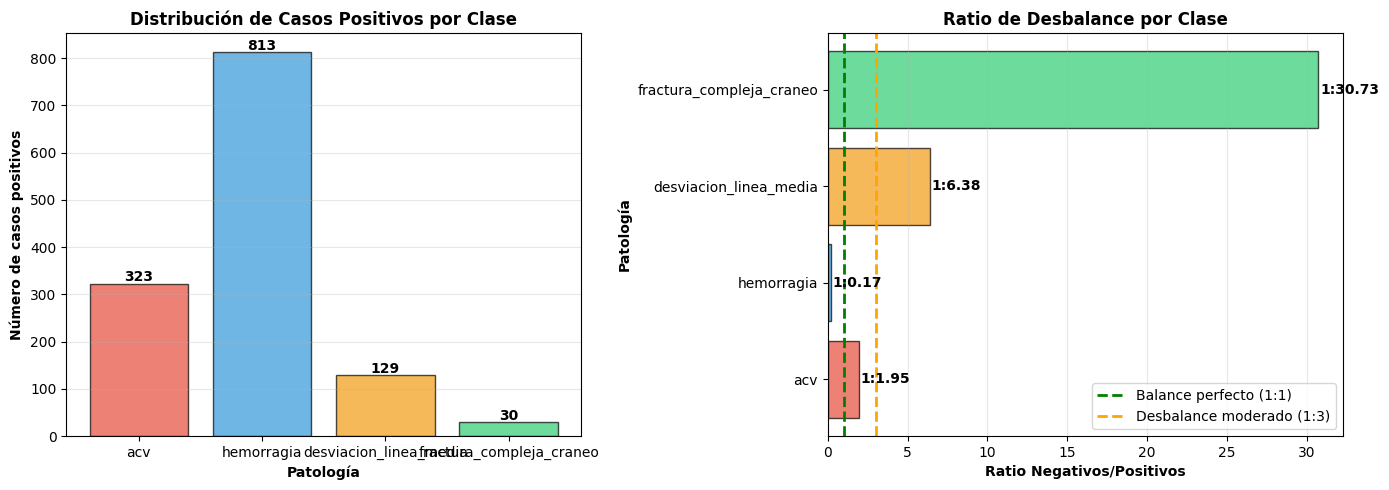

In [6]:
# VISUALIZACIÓN DEL DESBALANCE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de clases positivas
positivos = [class_counts[p]['positivos'] for p in patologias]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

axes[0].bar(patologias, positivos, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Patología', fontweight='bold')
axes[0].set_ylabel('Número de casos positivos', fontweight='bold')
axes[0].set_title('Distribución de Casos Positivos por Clase', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (pat, count) in enumerate(zip(patologias, positivos)):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Gráfico 2: Ratio de desbalance
ratios_display = [class_counts[p]['negativos']/class_counts[p]['positivos'] for p in patologias]

axes[1].barh(patologias, ratios_display, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Ratio Negativos/Positivos', fontweight='bold')
axes[1].set_ylabel('Patología', fontweight='bold')
axes[1].set_title('Ratio de Desbalance por Clase', fontweight='bold', fontsize=12)
axes[1].axvline(x=1, color='green', linestyle='--', linewidth=2, label='Balance perfecto (1:1)')
axes[1].axvline(x=3, color='orange', linestyle='--', linewidth=2, label='Desbalance moderado (1:3)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (pat, ratio) in enumerate(zip(patologias, ratios_display)):
    axes[1].text(ratio + 0.1, i, f'1:{ratio:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()



## 2. Preparación de datos y vectorización

Transformamos el texto médico (campo `Hallazgos`) en features numéricas usando TF-IDF, manteniendo la misma configuración del notebook de Modelos Tradicionales para garantizar comparabilidad.

In [7]:
# Vectorización TF-IDF del texto médico
X_text = df['Hallazgos'].astype(str)

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X = vectorizer.fit_transform(X_text)

print("="*60)
print("VECTORIZACIÓN TF-IDF")
print("="*60)
print(f"Shape de X: {X.shape}")
print(f"  - Muestras: {X.shape[0]}")
print(f"  - Features (términos TF-IDF): {X.shape[1]}")


VECTORIZACIÓN TF-IDF
Shape de X: (952, 200)
  - Muestras: 952
  - Features (términos TF-IDF): 200


## 3. División Train/Test Estratificada

**Buena práctica crítica**: Realizamos el split train/test ANTES de aplicar oversampling para prevenir data leakage.

### Principios aplicados:
1. **Estratificación**: Preserva las proporciones de cada clase en train y test
2. **Test intacto**: El conjunto de test NUNCA se modifica con oversampling
3. **Reproducibilidad**: random_state=42 permite replicar resultados
4. **Proporciones**: 80% train, 20% test (estándar en ML)


In [8]:
# Diccionario para almacenar los splits de cada patología
splits_data = {}

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    y = df[patologia].values
    
    # Split estratificado (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y  # Mantiene proporciones en ambos conjuntos
    )
    
    # Almacenar para uso posterior
    splits_data[patologia] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    # Mostrar distribución
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    print(f"  TRAIN SET ({len(y_train)} muestras):")
    print(f"    Negativos (0): {train_counts[0]:3d} ({train_counts[0]/len(y_train)*100:5.2f}%)")
    print(f"    Positivos (1): {train_counts[1]:3d} ({train_counts[1]/len(y_train)*100:5.2f}%)")
    
    print(f"\n  TEST SET ({len(y_test)} muestras):")
    print(f"    Negativos (0): {test_counts[0]:3d} ({test_counts[0]/len(y_test)*100:5.2f}%)")
    print(f"    Positivos (1): {test_counts[1]:3d} ({test_counts[1]/len(y_test)*100:5.2f}%)")
    
    # Verificar que las proporciones se preservaron
    train_ratio = train_counts[1] / len(y_train)
    test_ratio = test_counts[1] / len(y_test)
    diff = abs(train_ratio - test_ratio) * 100
    
    print(f"\n   Diferencia de proporciones train vs test: {diff:.2f}%", end="")
    if diff < 2:
        print(" (Estratificación correcta)")
    else:
        print(" ( Revisar estratificación)")

print(f"\n{'='*70}")
print(" División train/test completada para todas las patologías")
print(f"{'='*70}")


──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────
  TRAIN SET (761 muestras):
    Negativos (0): 503 (66.10%)
    Positivos (1): 258 (33.90%)

  TEST SET (191 muestras):
    Negativos (0): 126 (65.97%)
    Positivos (1):  65 (34.03%)

   Diferencia de proporciones train vs test: 0.13% (Estratificación correcta)

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────
  TRAIN SET (761 muestras):
    Negativos (0): 111 (14.59%)
    Positivos (1): 650 (85.41%)

  TEST SET (191 muestras):
    Negativos (0):  28 (14.66%)
    Positivos (1): 163 (85.34%)

   Diferencia de proporciones train vs test: 0.07% (Estratificación correcta)

──────────────────────────────────────────────────────────────────────
Patología: DESVIACION_LINEA_MEDIA
─────────────────────────────────────────────

## 4. Técnica de Oversampling: Random OverSampler (ROS)

### Justificación

**ROS** duplica registros reales existentes del conjunto minoritario.
Es la técnica adecuada para `hemorragia` y `acv` porque:

- Su léxico diagnóstico es explícito y estable (términos como *hemorragia subaracnoidea*,
  *infarto isquémico* aparecen de forma consistente)
- Duplicar casos reales preserva la integridad clínica del texto
- El desbalance moderado de `acv` (1:1.3) no requiere generación sintética

**Por qué NO se usa SMOTE:**  
SMOTE interpola entre vectores TF-IDF para generar puntos intermedios. En texto médico
esto produce vectores de frecuencia de términos que no corresponden a ningún reporte
real ni clínicamente plausible — esencialmente ruido en el espacio de features.
Para las clases críticas (`desviacion_linea_media`, `fractura_compleja_craneo`) se
utiliza generación LLM con imitación de estilo (ver notebook 1b).

**Principio preservado:** ROS se aplica **exclusivamente sobre el conjunto de entrenamiento**.

In [9]:
def aplicar_ros(X, y, random_state=42):
    """Aplica Random OverSampler al conjunto de entrenamiento."""
    sampler = RandomOverSampler(random_state=random_state)
    X_res, y_res = sampler.fit_resample(X, y)
    return X_res, y_res

print('Función ROS definida.')

Función ROS definida.


## 5. Aplicación de ROS

Aplicamos ROS únicamente a `acv` y `hemorragia`. Las clases escasas
(`desviacion_linea_media`, `fractura_compleja_craneo`) se tratan en el notebook 1b
con augmentation LLM.

In [10]:
# ROS solo para acv y hemorragia
# desviacion_linea_media y fractura_compleja_craneo → notebook 1b
CLASES_ROS = ['acv']
CLASES_LLM = ['desviacion_linea_media', 'fractura_compleja_craneo']

print('=' * 70)
print('APLICACIÓN DE RANDOM OVERSAMPLER (ROS)')
print('=' * 70)
print('  Solo en conjuntos de entrenamiento | Test SIN MODIFICAR\n')

ros_data = {}

for patologia in patologias:
    X_train = splits_data[patologia]['X_train']
    y_train = splits_data[patologia]['y_train']
    X_test  = splits_data[patologia]['X_test']
    y_test  = splits_data[patologia]['y_test']

    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")

    train_before = Counter(y_train)
    print(f"  ANTES  → Neg: {train_before[0]:4d} | Pos: {train_before[1]:4d} | Ratio 0:1 = {train_before[0]/max(train_before[1],1):.1f}:1")

    if patologia in CLASES_ROS:
        X_bal, y_bal = aplicar_ros(X_train, y_train)
        train_after  = Counter(y_bal)
        added        = train_after[1] - train_before[1]
        print(f"  DESPUÉS → Neg: {train_after[0]:4d} | Pos: {train_after[1]:4d} | +{added} duplicados (ROS)")
        nota = 'ROS aplicado'
    else:
        # Clases escasas: se pasan sin modificar; el balanceo real viene del notebook 1b
        X_bal, y_bal = X_train, y_train
        added        = 0
        print(f"  SIN ROS → augmentation LLM en notebook 1b")
        nota = 'LLM augmentation (notebook 1b)'

    test_counts = Counter(y_test)
    print(f"  TEST (intacto) → Neg: {test_counts[0]:4d} | Pos: {test_counts[1]:4d}")

    ros_data[patologia] = {
        'X_train_balanced': X_bal,
        'y_train_balanced': y_bal,
        'X_test':           X_test,
        'y_test':           y_test,
        'samples_added':    added,
        'metodo':           nota
    }

print(f"\n{'='*70}")
print('ROS aplicado a acv y hemorragia. Clases escasas sin modificar (→ notebook 1b).')
print(f"{'='*70}")

APLICACIÓN DE RANDOM OVERSAMPLER (ROS)
  Solo en conjuntos de entrenamiento | Test SIN MODIFICAR


──────────────────────────────────────────────────────────────────────
Patología: ACV
  ANTES  → Neg:  503 | Pos:  258 | Ratio 0:1 = 1.9:1
  DESPUÉS → Neg:  503 | Pos:  503 | +245 duplicados (ROS)
  TEST (intacto) → Neg:  126 | Pos:   65

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
  ANTES  → Neg:  111 | Pos:  650 | Ratio 0:1 = 0.2:1
  SIN ROS → augmentation LLM en notebook 1b
  TEST (intacto) → Neg:   28 | Pos:  163

──────────────────────────────────────────────────────────────────────
Patología: DESVIACION_LINEA_MEDIA
  ANTES  → Neg:  658 | Pos:  103 | Ratio 0:1 = 6.4:1
  SIN ROS → augmentation LLM en notebook 1b
  TEST (intacto) → Neg:  165 | Pos:   26

──────────────────────────────────────────────────────────────────────
Patología: FRACTURA_COMPLEJA_CRANEO
  ANTES  → Neg:  737 | Pos:   24 | Ratio 0:1 = 30.7:1
  SIN ROS → augmentation 

## 6. Visualización: antes vs después del balanceo

In [11]:
# Nota: SMOTE eliminado del pipeline
# ─────────────────────────────────────────────────────────────
# SMOTE opera sobre vectores TF-IDF interpolando entre puntos vecinos.
# El resultado son frecuencias de términos que no corresponden a ningún
# texto médico existente — ruido semántico, no variabilidad clínica real.
#
# Para las clases escasas (desviacion_linea_media, fractura_compleja_craneo)
# se usa augmentation LLM (notebook 1b): el modelo genera reportes sintéticos
# imitando el estilo de reportes reales, preservando coherencia clínica.
#
# Referencia: Veselovsky et al. (2023). Stanford HAI.
print('SMOTE descartado del pipeline. Ver notebook 1b para augmentation LLM.')

SMOTE descartado del pipeline. Ver notebook 1b para augmentation LLM.


## 6. Visualización: distribución antes vs después del balanceo

Mostramos el efecto de ROS en `acv` y `hemorragia`, y el estado sin modificar
de las clases escasas que serán tratadas en el notebook 1b.

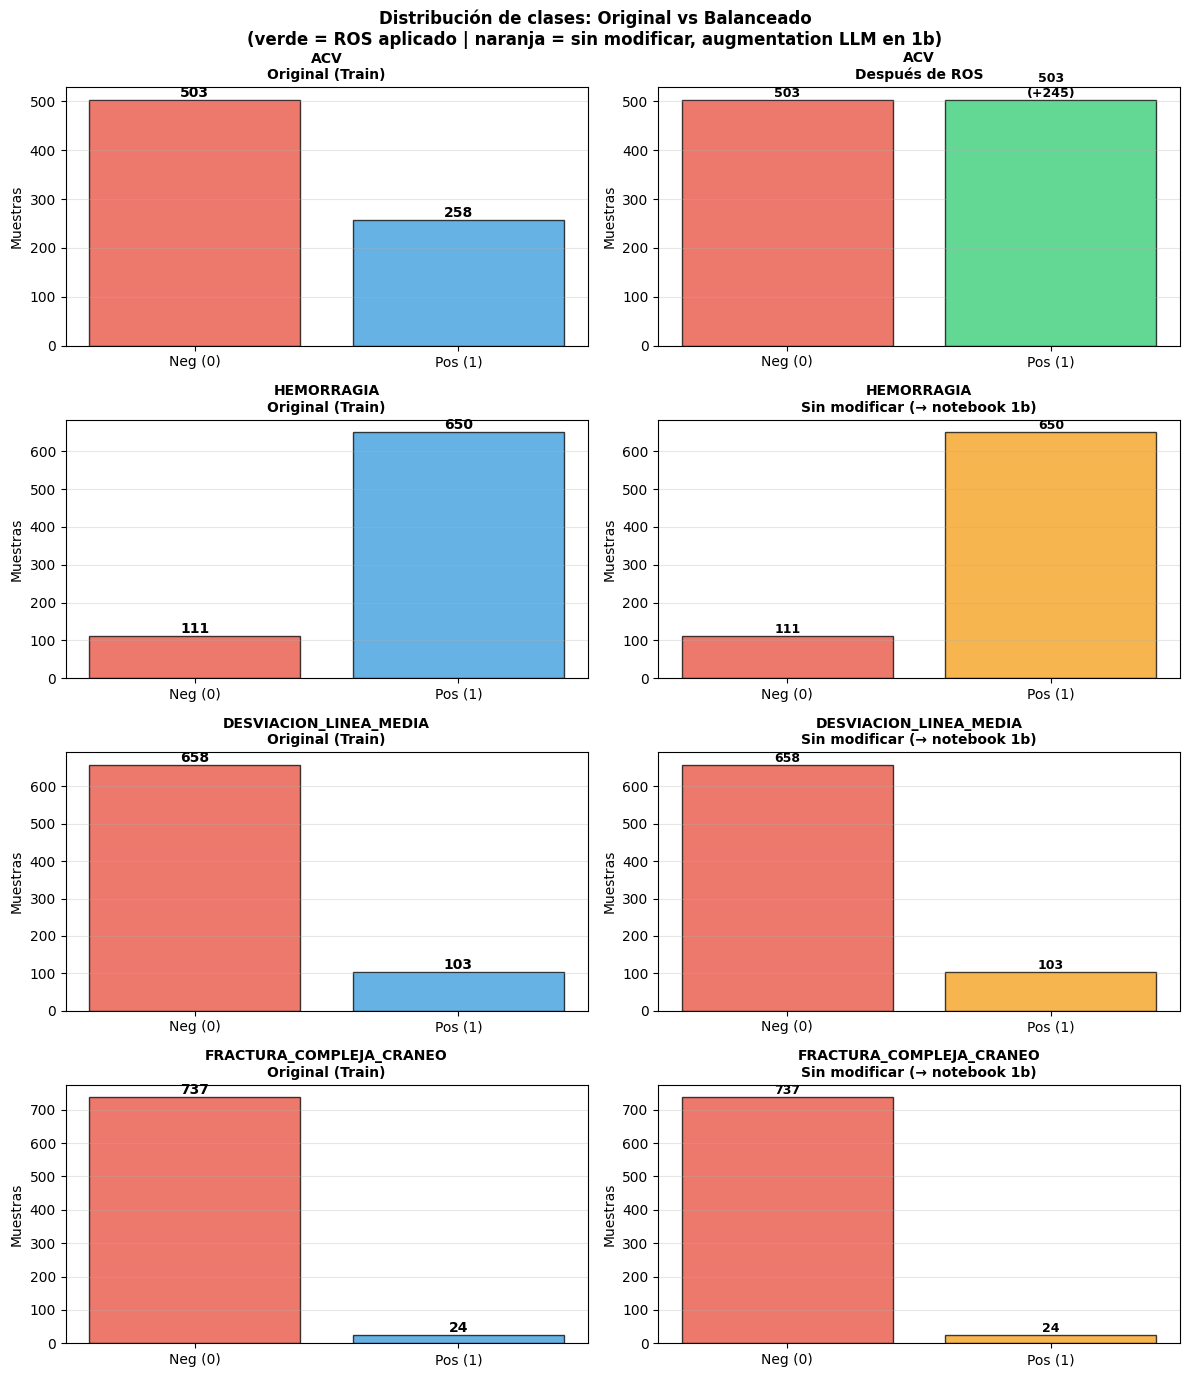

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
colors_neg = '#e74c3c'
colors_pos = '#3498db'
colors_ros = '#2ecc71'

for idx, patologia in enumerate(patologias):
    y_orig = splits_data[patologia]['y_train']
    y_bal  = ros_data[patologia]['y_train_balanced']

    orig_c = Counter(y_orig)
    bal_c  = Counter(y_bal)
    metodo = ros_data[patologia]['metodo']

    # — Original —
    ax1 = axes[idx, 0]
    bars = ax1.bar(['Neg (0)', 'Pos (1)'],
                   [orig_c[0], orig_c[1]],
                   color=[colors_neg, colors_pos], alpha=0.75, edgecolor='black')
    ax1.set_title(f'{patologia.upper()}\nOriginal (Train)', fontweight='bold', fontsize=10)
    ax1.set_ylabel('Muestras')
    ax1.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, [orig_c[0], orig_c[1]]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 str(int(v)), ha='center', va='bottom', fontweight='bold')

    # — Balanceado —
    ax2 = axes[idx, 1]
    c_pos = colors_ros if patologia in CLASES_ROS else '#f39c12'
    bars2 = ax2.bar(['Neg (0)', 'Pos (1)'],
                    [bal_c[0], bal_c[1]],
                    color=[colors_neg, c_pos], alpha=0.75, edgecolor='black')
    etiqueta = 'Después de ROS' if patologia in CLASES_ROS else 'Sin modificar (→ notebook 1b)'
    ax2.set_title(f'{patologia.upper()}\n{etiqueta}', fontweight='bold', fontsize=10)
    ax2.set_ylabel('Muestras')
    ax2.grid(axis='y', alpha=0.3)
    for bar, v, orig in zip(bars2, [bal_c[0], bal_c[1]], [orig_c[0], orig_c[1]]):
        diff = int(v - orig)
        label = str(int(v)) + (f'\n(+{diff})' if diff > 0 else '')
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 label, ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Distribución de clases: Original vs Balanceado\n'
             '(verde = ROS aplicado | naranja = sin modificar, augmentation LLM en 1b)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/oversampling_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumen del balanceo aplicado

In [13]:
print('=' * 70)
print('RESUMEN DE BALANCEO')
print('=' * 70)
print(f"{'Patología':<30} {'Original':>9} {'Balanceado':>11} {'Añadidas':>9} {'Método'}")
print('-' * 75)

for p in patologias:
    orig  = int(splits_data[p]['y_train'].sum())
    bal   = int(ros_data[p]['y_train_balanced'].sum())
    added = ros_data[p]['samples_added']
    met   = ros_data[p]['metodo']
    print(f"{p:<30} {orig:>9} {bal:>11} {added:>9}  {met}")

print()
print('Clases escasas (desviacion_linea_media, fractura_compleja_craneo):')
print('  → Augmentation con LLM en notebook 1b (imitación de estilo, temperatura 0.9)')
print('  → Meta: ~300 sintéticos por clase sobre los ~52-60 reales existentes')

RESUMEN DE BALANCEO
Patología                       Original  Balanceado  Añadidas Método
---------------------------------------------------------------------------
acv                                  258         503       245  ROS aplicado
hemorragia                           650         650         0  LLM augmentation (notebook 1b)
desviacion_linea_media               103         103         0  LLM augmentation (notebook 1b)
fractura_compleja_craneo              24          24         0  LLM augmentation (notebook 1b)

Clases escasas (desviacion_linea_media, fractura_compleja_craneo):
  → Augmentation con LLM en notebook 1b (imitación de estilo, temperatura 0.9)
  → Meta: ~300 sintéticos por clase sobre los ~52-60 reales existentes


## 8. Exportación

Guardamos el dataset con ROS en Excel para uso en los notebooks 2 y 3.
Las clases escasas se exportan sin modificar — el notebook 1b las augmenta
y produce su propio archivo `train_augmentado_llm.xlsx`.

In [14]:
import os
from pathlib import Path

output_path = Path('../data/train_oversampling_data.xlsx')
output_path.parent.mkdir(parents=True, exist_ok=True)

print('=' * 70)
print('EXPORTACIÓN — train_oversampling_data.xlsx')
print('=' * 70)

# Reconstruir índices del split train/test de forma robusta
from sklearn.model_selection import train_test_split as tts
idx_all = np.arange(len(df))
idx_train, idx_test = tts(
    idx_all,
    test_size=0.2,
    random_state=42,
    stratify=df['hemorragia'].values
)

df_train_base = df.iloc[idx_train].copy().reset_index(drop=True)
df_test_base  = df.iloc[idx_test].copy().reset_index(drop=True)

# Para ROS reconstruimos el df expandiendo filas duplicadas
ref_pat = 'hemorragia'
y_train_ref = splits_data[ref_pat]['y_train']
X_bal_ref   = ros_data[ref_pat]['X_train_balanced']
n_ros_total = X_bal_ref.shape[0]
n_orig      = len(df_train_base)

repeat_times = (n_ros_total // n_orig) + 1
df_train_ros = pd.concat([df_train_base] * repeat_times, ignore_index=True).iloc[:n_ros_total].copy()
df_train_ros.insert(0, 'tipo', ['original'] * n_orig + ['ROS_duplicado'] * (n_ros_total - n_orig))

df_test_base.insert(0, 'tipo', 'original')

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_train_base.to_excel(writer, sheet_name='Train_Original', index=False)
    df_train_ros.to_excel(writer, sheet_name='Train_ROS', index=False)
    df_test_base.to_excel(writer, sheet_name='Test', index=False)

    # Metadata
    meta = []
    for p in patologias:
        meta.append({
            'Patología': p,
            'Train original (positivos)': int(splits_data[p]['y_train'].sum()),
            'Train balanceado (positivos)': int(ros_data[p]['y_train_balanced'].sum()),
            'Muestras añadidas': ros_data[p]['samples_added'],
            'Método': ros_data[p]['metodo'],
            'Test (positivos)': int(splits_data[p]['y_test'].sum())
        })
    pd.DataFrame(meta).to_excel(writer, sheet_name='Metadata', index=False)

size_kb = output_path.stat().st_size / 1024
print(f'  Train_Original : {len(df_train_base)} filas')
print(f'  Train_ROS      : {len(df_train_ros)} filas')
print(f'  Test           : {len(df_test_base)} filas (solo reales)')
print(f'  Archivo guardado: {output_path} ({size_kb:.1f} KB)')
print()
print('Siguiente paso → ejecutar notebook 1b para augmentation LLM')
print('  de desviacion_linea_media y fractura_compleja_craneo.')

EXPORTACIÓN — train_oversampling_data.xlsx
  Train_Original : 761 filas
  Train_ROS      : 761 filas
  Test           : 191 filas (solo reales)
  Archivo guardado: ..\data\train_oversampling_data.xlsx (1025.9 KB)

Siguiente paso → ejecutar notebook 1b para augmentation LLM
  de desviacion_linea_media y fractura_compleja_craneo.
